# Trans Fictício BR — Avaliação de Qualidade de Dados
<a id="topo"></a>

[Home](../README.md)

**Autor:** Tiago Lima  
**Projeto:** Logística OTIF · Ciência de Dados & MLOps ponta a ponta  
**Cliente:** Trans Fictício BR  
**Data:** 04/08/2026  

**Objetivo:** avaliar qualidade, preenchimento, coerência semântica e consistência temporal da base analítica inicial do operacional. A empresa é ficticia e todos os dados são sintéticos, contudo este projeto teve aplicabilidade real e hoje se encontra em execução, mas devido ao fato do projeto ser exposto como meu portifólio pessoal, a empresa é ficticia e os dados são sintéticos

**Base principal analisada nesta etapa:** 
<details>
<summary><b>Base Operacional</b></summary>

 - [endereco](../../data/bronze/operacao/endereco.parquet) 
 - [entrega](../../data/bronze/operacao/entrega.parquet)
 - [estoque_snapshot](../../data/bronze/operacao/estoque_snapshot.parquet)
 - [item](../../data/bronze/operacao/fase.parquet)
 - [item](../../data/bronze/operacao/item.parquet)
 - [minuta](../../data/bronze/operacao/minuta.parquet) 
 - [modalidade](../../data/bronze/operacao/modalidade.parquet) 
 - [ocorrencia](../../data/bronze/operacao/ocorrencia.parquet) 
 - [ordem_coleta](../../data/bronze/operacao/ordem_coleta.parquet) 
 - [organizacao](../../data/bronze/operacao/organizacao.parquet) 
 - [pedido_fase](../../data/bronze/operacao/pedido_fase.parquet) 
 - [pedido_item](../../data/bronze/operacao/pedido_item.parquet) 
 - [pedido](../../data/bronze/operacao/pedido.parquet) 
 - [retirada_base](../../data/bronze/operacao/retirada_base.parquet) 
 - [rota](../../data/bronze/operacao/rota.parquet) 
 - [tipo_ocorrencia](../../data/bronze/operacao/tipo_ocorrencia.parquet) 
 - [transportador](../../data/bronze/operacao/transportador.parquet)
 - [veiculo](../../data/bronze/operacao/veiculo.parquet)
</details>

**Perguntas-guia:** Para cada fonte de dados devem ser analisados:
- Os campos críticos vêm preenchidos?
- Os categóricos fazem sentido para o negócio?
- As datas respeitam a ordem temporal esperada?
- Há sinais de leakage?
- Quais campos parecem confiáveis para o MVP agora?
- Existe linhas duplicadas?
- Existe nulos e eles são validos?
- Existem numeros impossíveis como: Data final menor do que data inicial, quatidade negativas, etc?
- Quais os tipos de dados e eles são coerentes com o rótulo?

**Perguntas-guia desta etapa:**
- Os campos críticos vêm preenchidos, e o que está vazio impede alguma análise?
- Os categóricos têm os valores que o negócio descreve, ou existe categoria estranha na cauda?
- As datas respeitam a ordem dos eventos, ou existe número impossível?
- Há duplicata de chave de negócio, que quebraria junção e inflaria indicador?
- O que precisa ser tratado na camada Silver, e o que precisa ser reportado ao dono do sistema?

**Como este documento é organizado:** cada seção abre com o que será examinado,
mostra a evidência em código e fecha com uma 

**Nota Técnica** contendo o que foi observado, por que importa e qual a ação. As notas técnicas são a matéria-prima
do relatório entregue ao cliente.

## Sumário

| Seção | O que examina |
|---|---|
| [1. Imports e configurações](#secao-1) | ambiente e reprodutibilidade |
| [2. A fotografia dos dados](#secao-2) | de qual carga estamos falando |
| [3. Carga das tabelas](#secao-3) | o que veio do Bronze |
| [4. Visão geral](#secao-4) | tamanho, tipos e forma de cada tabela |
| [5. Completude](#secao-5) | o que está vazio, e onde isso dói |


<a id="secao-1"></a>

# 1. Imports e Configurações

O acesso aos dados nunca é feito por caminho cru nem por credencial escrita aqui, tudo passa pelo pacote do projeto. Assim este notebook roda na máquina dequalquer pessoa que tenha o `.env` preenchido, sem editar uma linha.

## 1.1. Imports

In [1]:
import json
import re
import sys
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from logistica_otif_mlops import qualidade

## 1.2. Configurações Gerais

In [2]:
RAIZ = Path.cwd().parents[1] if Path.cwd().name == "operacional" else Path.cwd()
BRONZE = RAIZ / "data" / "bronze" / "operacao"

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

print(f"Raiz do projeto: {RAIZ}")
print(f"Bronze: {BRONZE}")

Raiz do projeto: /home/neviah/projetos/logistica-otif-mlops
Bronze: /home/neviah/projetos/logistica-otif-mlops/data/bronze/operacao


## 1.3. Versões 
Registrar a versão de cada biblioteca é o que permite responder, daqui a um ano, por que o mesmo código produziu outro resultado.

In [3]:
print(f"Python  {sys.version.split()[0]}")
for modulo in (pd, sns):
    print(f"{modulo.__name__:<8}{modulo.__version__}")

Python  3.12.3
pandas  3.0.5
seaborn 0.13.2


## Nota Técnica

**Observado:** o ambiente carrega apenas quatro dependências de análise, e o acesso ao dado é intermediado pelo pacote `logistica_otif_mlops`.

**Por que importa:** o notebook não conhece host, senha nem caminho absoluto, isso o torna executável por outra pessoa e publicável em repositório aberto sem vazar credencial.

**Ação:** nenuma, é a configuração esperada.

<a id="secao-2"></a>
# 2. A fotografia dos dados

Toda análise de qualidade descreve um instante, sem dizer qual a conclusão fica sem validade: a base muda todo dia, e um defeito corrigido ontem continuaria sendo reportado. O manifesto da ingestão responde a isso e é lido, não digitado para não desatualizar.

In [4]:
manifesto = json.loads((BRONZE.parent / "_manifesto.json").read_text(encoding="utf-8"))
conjuntos = pd.DataFrame(manifesto["conjuntos"])

print(f"Carga concluída em: {manifesto['carga_concluida_em']}")
print(f"Conjuntos ingeridos: {len(conjuntos)}")
print(f"Linhas no total:     {conjuntos['linhas'].sum():,.0f}")

conjuntos[
    ["conjunto", "origem", "linhas", "colunas", "megabytes"]
].sort_values("linhas", ascending=False)

Carga concluída em: 2026-08-18T18:54:23.511246+00:00
Conjuntos ingeridos: 22
Linhas no total:     35,998,842


,conjunto,origem,linhas,colunas,megabytes
15,pedido_fase,operacao.pedido_fase,14589229,5,300.40
16,pedido_item,operacao.pedido_item,7728077,4,61.02
12,ordem_coleta,operacao.ordem_coleta,3662275,6,69.19
0,custos,v1/custos,3083852,7,31.35
5,entrega,operacao.entrega,2664991,11,59.73
1,faturamentos,v1/faturamentos,1782616,8,24.35
14,pedido,operacao.pedido,1776391,17,66.71
17,retirada_base,operacao.retirada_base,364905,5,4.48
9,minuta,operacao.minuta,214692,8,4.09
6,estoque_snapshot,operacao.estoque_snapshot,56008,8,0.72


## Nota Técnica

**Observado:** a análise recai sobre a carga do Bronze concluída na data acima, com 22 conjuntos do domínio operacional e financeiro e 35,9 milhões de linhas. O Bronze é cópia fiel da origem, sem nenhuma transformação aplicada.

**Por que importa:** qualquer número deste documento pode ser reproduzido apartir desta mesma carga e como o Bronze não corrige nada, o que aparecer aqui como defeito é defeito do sistema de origem, não do nosso pipeline.

**Ação:** nenhuma. Serve de referência para todo o restante do documento.

<a id="secao-3"></a>
# 3. Carga das tabelas do domínio operacional

As 18 tabelas entram de uma vez, em um dicionário, trabalhar com todas juntas, permite aplicar o mesmo diagnóstico em série e comparar os resultados, em vez de repetir a mesma inspeção dezoito vezes.

In [5]:
tabelas = {
    arquivo.stem: pd.read_parquet(arquivo)
    for arquivo in sorted(BRONZE.glob("*.parquet"))
}

inventario = pd.DataFrame([
    {"tabela": nome, "linhas": len(df), "colunas": len([c for c in df.columns
                                                        if not c.startswith("_")])}
    for nome, df in tabelas.items()
]).sort_values("linhas", ascending=False)

print(f"{len(tabelas)} tabelas carregadas · {inventario['linhas'].sum():,.0f} linhas")
inventario

18 tabelas carregadas · 31,132,247 linhas


,tabela,linhas,colunas
11,pedido_fase,14589229,5
12,pedido_item,7728077,4
8,ordem_coleta,3662275,6
1,entrega,2664991,11
10,pedido,1776391,17
13,retirada_base,364905,5
5,minuta,214692,8
2,estoque_snapshot,56008,8
7,ocorrencia,48793,7
0,endereco,19697,12


## Nota Técnica

**Observado:** as 18 tabelas foram carregadas do Bronze. O volume é bastante desigual, pois cinco tabelas concentram quase toda a massa (fases, itens de pedido, ordens de coleta, entregas e pedidos), enquanto as tabelas de domínio têm poucas dezenas de linhas.

**Por que importa:** o esforço de análise deve seguir essa proporção. Onde estão os milhões de linhas estão também as features do modelo e o alvo e é ali que um defeito custa caro. As tabelas de domínio precisam apenas de uma verificação de sanidade.

**Ação:** priorizar o exame das tabelas de movimento; tratar as tabelas de domínio em bloco.

<a id="secao-4"></a>
# 4. Visão geral
**O que existe em cada tabela?** Antes de procurar defeito é preciso saber o que há. Esta seção monta o perfil de todas as colunas de todas as tabelas como: tipo, preenchimento e variedade, é o mapa que orienta onde olhar em seguida.

In [6]:
perfis = pd.concat(
    [qualidade.perfil(df, nome) for nome, df in tabelas.items()],
    ignore_index=True,
)

print(f"{len(perfis)} colunas analisadas em {perfis['tabela'].nunique()} tabelas")
print()
print("Distribuição dos tipos:")
print(perfis["tipo"].value_counts().to_string())

133 colunas analisadas em 18 tabelas

Distribuição dos tipos:
tipo
int64             45
str               44
float64           15
object            11
datetime64[us]    10
bool               8


In [7]:
# colunas constantes não informam nada: o mesmo valor em todas as linhas
constantes = perfis[(perfis["distintos"] <= 1) & (perfis["nulos"] == 0)]
print(f"Colunas com valor único (candidatas a descarte): {len(constantes)}")
if len(constantes):
    display(constantes[["tabela", "coluna", "exemplo"]])

Colunas com valor único (candidatas a descarte): 4


,tabela,coluna,exemplo
45,item,ativo,True
56,modalidade,ativo,True
70,ordem_coleta,status,COLETADA
127,transportador,ativo,True


## Nota Técnica

**Observado:** o perfil cobre todas as colunas do domínio operacional. Os tipos vieram preservados do banco, o que confirma que o Parquet manteve a tipagem da origem, sem transformar número em texto no caminho.

**Por que importa:** tipo preservado significa que somas e comparações de data podem ser feitas direto, sem conversão prévia e se o Bronze tivesse sido gravado em CSV, cada coluna chegaria como texto e a primeira conta exigiria uma conversão manual, com risco de erro silencioso.

**Ação:** nenhuma neste ponto. O perfil é insumo para as seções seguintes.

<a id="secao-5"></a>
# 5. Completude 
**O que está vazio, e onde isso dói?** Campo vazio não é necessariamente defeito, existem três situações diferentes e confundi-las, leva a tratar o que não precisa e ignorar o que precisa:
 1. **Vazio legítimo:** o evento ainda não aconteceu (entrega em trânsito não tem   data de chegada), é informação, não ausência.
 2. **Vazio por regra:** o campo não se aplica àquele caso (armazenagem não tem   número de pedido, porque fatura por competência).
 3. **Vazio por falha:** deveria estar preenchido e não está, este é o defeito.

In [8]:
com_nulos = (perfis[perfis["nulos"] > 0]
             .sort_values("pct_nulo", ascending=False)
             [["tabela", "coluna", "tipo", "nulos", "pct_nulo"]])

print(f"Colunas com algum vazio: {len(com_nulos)} de {len(perfis)}")
com_nulos

Colunas com algum vazio: 21 de 133


,tabela,coluna,tipo,nulos,pct_nulo
9,endereco,latitude,object,19697,100.00
10,endereco,longitude,object,19697,100.00
64,ocorrencia,dt_cancelada,object,48793,100.00
89,pedido,campanha_id,float64,1411799,79.48
81,organizacao,dt_cancelamento,object,135,56.25
60,ocorrencia,entrega_id,float64,26711,54.74
22,entrega,dt_entrada_base,datetime64[us],1427228,53.55
19,entrega,recebedor,str,1261740,47.35
49,minuta,veiculo_id,float64,85050,39.61
125,transportador,cnpj,str,7,36.84


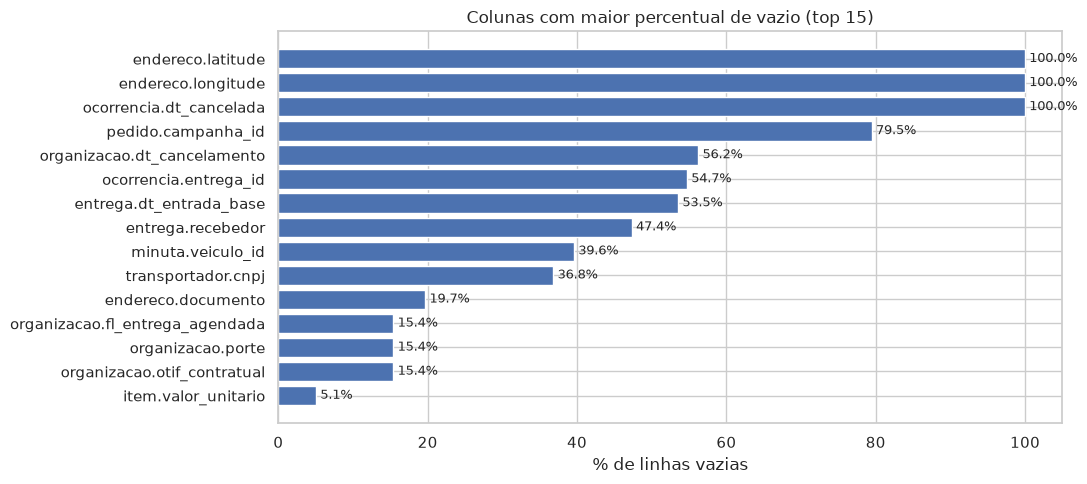

In [9]:
fig, eixo = plt.subplots()
dados = com_nulos.head(15).iloc[::-1]
rotulos = dados["tabela"] + "." + dados["coluna"]

barras = eixo.barh(rotulos, dados["pct_nulo"], color="#4C72B0")
eixo.set_xlabel("% de linhas vazias")
eixo.set_title("Colunas com maior percentual de vazio (top 15)")
eixo.bar_label(barras, fmt="%.1f%%", padding=3, fontsize=9)
eixo.set_xlim(0, 105)
plt.tight_layout()
plt.show()

## Nota Técnica

**Observado:** as colunas com maior percentual de vazio são, em sua maioria, vazios legítimos ou por regra. Os casos que merecem atenção são os que se enquadram na terceira categoria, e eles precisam ser confirmados um a um contra a regra de negócio antes de virarem recomendação.

**Por que importa:** tratar vazio legítimo como defeito produz duas consequências ruins. No relatório, infla a lista de problemas e faz o cliente perder confiança no diagnóstico. No pipeline, leva a preencher com valorinventado um campo cuja ausência era o próprio dado.

**Ação:** classificar cada coluna vazia nas três categorias antes de propor tratamento. As confirmadas como falha entram no registro de achados com aseveridade correspondente.

**Classificação:** Classificar as colunas nulas como legítimo, regra ou falha.
- **endereco.latitude e endereco.longitude:** Legítimo, pois estas colunas seriam usadas para calcular rotas via apis googlemaps com o objetivo inicial de calcular e prestar contas sobre emissão de CO² na atmosfera. Com emissão de CO² se trata de um projeto futuro este dado naõ esta sendo preenchido, com isso não foi colocado como campos obrigatórios, pois esta coluna pode ser carrega posteriormente via apis googlemaps.
- **ocorrencia.dt_cancelada:** Legítimo, pois na regra de negócio vigente não se registra cancelamentos de ocorrencia, pois ocorrências pode ocorrer ou não.
- **pedido.campanha_id:** Legítimo, pois nem todos os pedidos pertencem a uma campanha
- **organizacao.dt_cancelamento:** Legitimo, pois dt_cancelamente nulos são clientes ativos
- **ocorrencia.entrega_id:** Legítimo, pois as ocorrências podem estar atrelados a entrega comprometendo todos os pedidos desta entrega ou apenas ocorrencias ao pedido, por exemplo, a entrega foi barrado pela fiscalização na balança, ou a ocorrencia foi no pedido devido ao cliente ausente no local ou se recusou a receber a mercadoria.
- **entrega.dt_entra_base:** Legítimo, pois esta coluna apresenta pedidos ou materiais que ainda não foi feito o processo de entrada na base ou dado a baixa.
- **entrega.recebedor:** Legítimo se as entregas ainda estiverem em andamento, caso contrario pode ser um erro. Pode ser analisado como numeros impossíveis nas etapas posteriores.
- **minuta.veículo:** Legítimo se as minutas forem de modalidade aérea. Sera analisado detalhadamente na etapa de numeros impossíveis.
- **transportador.cnpj:** Erro, pois todos transportadores devem ter CNPJ, mas acredito que este campo nulo não interferira nas analises posteriores, mas é bom reportar no relatório.
- **endereco.documento:** Sem informação, pois não sei informar o graou de importancia e o objetivo desta coluna documento no cadastro de endereço.
- **organizacao.fl_entrega_agendada:** Legítimo, pois o dendereço pode ou não ter entregas agendadas.
- **organizacao.porte:** Erro, o porte é importante para mensurar margens, ou seja, se inputar um placeholder como "NÃO DEFINIDO" teremos o porte NÃO DEFINIDO com margem de 65% por exemplo e este dado faz derrubar as medias dos outros portes, pois os "65%" pode estar distribuidos em micro, pequena, media, grande, mega, NÃO DEFINIDO ou NULO acaba sendo dado perdido.
- **organizacao.otif_contratual:** Erro, otif_contratual é importante para mensurar se a otif prometida não esta acima da capacidade da empresa.
- **item.valor:** Legítimo se for materiais promocionais e etc.

## Registro de achados

Os achados de todas as seções são acumulados aqui. No fechamento, esta estrutura
vira a tabela do relatório entregue ao cliente, ordenada por severidade. O
critério de severidade adotado:

| Severidade | Critério |
|---|---|
| **alta** | impede uma análise, distorce indicador ou compromete o modelo |
| **media** | exige tratamento no pipeline, sem impedir a análise |
| **baixa** | incomoda, mas não muda conclusão |

In [10]:
achados = qualidade.RegistroDeAchados()
print("registro iniciado")

registro iniciado


## 5.1. Verificação das classificações

A classificação acima é uma hipótese até ser testada. Vazio "legítimo porque o
evento ainda não aconteceu" só é legítimo se os números confirmarem: se 47% de
um campo está vazio e apenas 0,05% dos registros está em andamento, a explicação
não se sustenta.

Esta seção testa as quatro hipóteses que dependem de verificação.

In [11]:
entrega = tabelas["entrega"]
minuta = tabelas["minuta"]
modalidade = tabelas["modalidade"]

# Hipótese 1: recebedor vazio porque a entrega está em andamento
print("HIPÓTESE 1 · recebedor vazio = entrega em andamento")
print(f"  entregas sem recebedor        {entrega['recebedor'].isna().sum():>10,}")
print(f"  entregas em trânsito          {entrega['fl_sucesso'].isna().sum():>10,}")
print("\n  quem realmente está sem recebedor:")
print(entrega[entrega["recebedor"].isna()]["tipo_perna"].value_counts().to_string())

# a comparação decisiva: o sistema CONSEGUE capturar recebedor?
print("\n  o campo é preenchido em outros tipos de perna?")
comparacao = (entrega.assign(sem_recebedor=entrega["recebedor"].isna())
              .groupby("tipo_perna")["sem_recebedor"]
              .agg(entregas="count", sem_recebedor="sum"))
comparacao["pct_vazio"] = (100 * comparacao["sem_recebedor"] / comparacao["entregas"]).round(2)
print(comparacao.to_string())

HIPÓTESE 1 · recebedor vazio = entrega em andamento
  entregas sem recebedor         1,261,740
  entregas em trânsito               1,357

  quem realmente está sem recebedor:
tipo_perna
TRANSFERENCIA_BASE    1239076
DIRETA                  22411
ULTIMA_MILHA_BASE         253

  o campo é preenchido em outros tipos de perna?


                    entregas  sem_recebedor  pct_vazio
tipo_perna                                            
DIRETA                553688          22411       4.05
TRANSFERENCIA_BASE   1239076        1239076     100.00
ULTIMA_MILHA_BASE     872227            253       0.03


In [12]:
# Hipótese 2: veículo vazio porque a minuta é aérea
print("HIPÓTESE 2 · minuta sem veículo = embarque aéreo")
com_modal = minuta.merge(modalidade[["id", "codigo"]],
                         left_on="modalidade_id", right_on="id", suffixes=("", "_mod"))
sem_veiculo = com_modal[com_modal["veiculo_id"].isna()]
print(f"  minutas sem veículo           {len(sem_veiculo):>10,}")
print("  por modalidade:")
print(sem_veiculo["codigo"].value_counts().to_string())

HIPÓTESE 2 · minuta sem veículo = embarque aéreo
  minutas sem veículo               85,050
  por modalidade:
codigo
AEREO    85050


In [13]:
# Hipótese 3: dt_entrada_base vazio porque a perna não passa por base
print("HIPÓTESE 3 · sem entrada na base = perna que não passa por base")
print(entrega[entrega["dt_entrada_base"].isna()]["tipo_perna"].value_counts().to_string())

pendentes = entrega[(entrega["tipo_perna"] == "TRANSFERENCIA_BASE")
                    & (entrega["dt_entrada_base"].isna())]
print(f"\n  transferências SEM entrada registrada: {len(pendentes):,}")

# dessas, quais já chegaram fisicamente? é a fila do Control Tower
chegou_sem_baixa = pendentes[pendentes["dt_chegada"].notna()]
print(f"  DESTAS, já chegaram na base:          {len(chegou_sem_baixa):,}")
print(f"  ainda em trânsito:                    {len(pendentes) - len(chegou_sem_baixa):,}")

if len(chegou_sem_baixa):
    espera = (pd.Timestamp("2026-07-28") - chegou_sem_baixa["dt_chegada"]).dt.days
    print(f"\n  dias parados aguardando baixa (mediana): {espera.median():.0f}")
    print(f"  caso mais antigo:                        {espera.max():.0f} dias")

HIPÓTESE 3 · sem entrada na base = perna que não passa por base
tipo_perna
ULTIMA_MILHA_BASE     872227
DIRETA                553688
TRANSFERENCIA_BASE      1313

  transferências SEM entrada registrada: 1,313
  DESTAS, já chegaram na base:          538
  ainda em trânsito:                    775

  dias parados aguardando baixa (mediana): 0
  caso mais antigo:                        33 dias


In [14]:
# Hipótese 4: porte e OTIF vazios são erro de cadastro
print("HIPÓTESE 4 · porte e OTIF contratual vazios")
organizacao = tabelas["organizacao"]
sem_porte = organizacao[organizacao["porte"].isna()]
print(f"  organizações sem porte        {len(sem_porte):>10,}")
print("  o que são essas organizações:")
print(sem_porte["tipo_parceria"].value_counts().to_string())
print(f"\n  sem OTIF contratual:          {organizacao['otif_contratual'].isna().sum():>10,}")

HIPÓTESE 4 · porte e OTIF contratual vazios
  organizações sem porte                37
  o que são essas organizações:
tipo_parceria
BASE      36
MATRIZ     1

  sem OTIF contratual:                  37


In [15]:
# Cobertura fiscal: item sem valor E com saldo em estoque
print("VERIFICAÇÃO EXTRA · cobertura fiscal")
item = tabelas["item"]
snapshot = tabelas["estoque_snapshot"]
sem_valor = set(item[item["valor_unitario"].isna()]["id"])
com_saldo = set(snapshot[snapshot["qtde_saldo"] > 0]["item_id"])
print(f"  itens sem valor unitário      {len(sem_valor):>10,}")
print(f"  DESTES, com saldo em estoque  {len(sem_valor & com_saldo):>10,}")

print("\nVERIFICAÇÃO EXTRA · transportador sem CNPJ")
print(tabelas["transportador"].query("cnpj.isna()")[["nome", "tipo"]].to_string(index=False))

VERIFICAÇÃO EXTRA · cobertura fiscal


  itens sem valor unitário             345
  DESTES, com saldo em estoque          79

VERIFICAÇÃO EXTRA · transportador sem CNPJ


                     nome          tipo
Trans Fictício BR Frota Própria FROTA_PROPRIA
 Marcos Silva Transportes    CARRETEIRO
        Do Vale Agregados    CARRETEIRO
             Irmãos Souza    CARRETEIRO
             Naldo Fretes    CARRETEIRO
        W. Costa Agregado    CARRETEIRO
           Trans Nakamura    CARRETEIRO


## Nota Técnica

**Observado:** das quatro hipóteses testadas, duas se confirmaram e duas foram
refutadas. Uma das refutações veio da operação, não dos dados: a leitura inicial
tratava a ausência de recebedor na transferência como legítima, e o conhecimento
do processo mostrou que não é.

| Hipótese | Veredicto | O que os números mostram |
|---|---|---|
| recebedor vazio = entrega em andamento | **refutada** | 1.261.740 vazios contra 1.357 entregas em trânsito. A ausência se concentra nas pernas de transferência para base |
| veículo vazio = minuta aérea | **confirmada** | as 85.050 minutas sem veículo são todas aéreas, sem exceção |
| sem entrada na base = perna que não passa por base | **confirmada, com resíduo** | a maioria é última milha e entrega direta. Restam 1.313 transferências sem baixa, analisadas adiante |
| porte e OTIF vazios = erro de cadastro | **refutada** | as 37 organizações sem porte são as 36 bases parceiras e a matriz, que não são clientes e por isso não têm esses atributos |

**O achado que a verificação revelou:** a ausência de recebedor **não é legítima**,
e a comparação entre tipos de perna prova isso:

| Tipo de perna | Entregas | Sem recebedor |
|---|---|---|
| Última milha (cliente final) | 872.227 | 253 (0,03%) |
| Transferência para base | 1.239.076 | **1.239.076 (100%)** |

O sistema captura recebedor sem dificuldade, como demonstram os 99,97% de
preenchimento na entrega ao cliente final. O campo fica vazio **exclusivamente**
na transferência para base. Não é limitação técnica, é lacuna de processo: a
carga é entregue fisicamente a alguém na base, e esse alguém não assina.

**Por que importa:** sem canhoto, não há como arbitrar a divergência clássica
entre transportadora e base. A transportadora afirma que entregou, a base afirma
que não recebeu, e não existe registro de quem recebeu a carga. Quando há perda
ou avaria, a responsabilidade fica indefinida, e o custo tende a ficar com quem
tiver menos poder de negociação.

Agrava o quadro o fato de que 1.237.763 dessas transferências **têm baixa dada na
base**. Ou seja, o sistema registra que a base recebeu, mas não registra quem.

**Ação:** reportar ao dono do sistema com recomendação de tornar o recebedor
obrigatório também na transferência, no aplicativo usado pelo motorista.

Os demais vazios (porte e OTIF em bases, CNPJ de carreteiro, veículo em minuta
aérea) são legítimos ou por regra, e entram no relatório como esclarecimento, não
como problema. Sobre o CNPJ, dos 7 transportadores sem o número, 6 são
carreteiros, que são pessoa física e possuem CPF, e o sétimo é a própria frota.

In [16]:
achados.anotar(
    tabela="item", coluna="valor_unitario",
    achado="SKU com saldo em estoque e sem valor fiscal (cobertura fiscal)",
    linhas=79, total=len(item), severidade="alta",
    impacto="impede calcular seguro por ad valorem e a valorização do estoque parado",
    acao="reportar ao cliente para completar o cadastro na origem",
)
achados.anotar(
    tabela="entrega", coluna="recebedor",
    achado="transferência para base sem registro de quem recebeu a carga",
    linhas=1239076, total=len(entrega), severidade="alta",
    impacto="sem canhoto não há como arbitrar divergência entre transportadora e base "
            "em caso de perda ou avaria",
    acao="tornar o campo obrigatório no aplicativo do motorista (ação na origem)",
)
print(f"achados registrados: {len(achados)}")

achados registrados: 2


# 6. Unicidade

Chave de negócio duplicada (`pedido.numero`, `minuta.numero`)

In [17]:
for tabela, chave in [("pedido", "numero"), ("minuta", "numero"),
                      ("organizacao", "sigla"), ("item", "codigo")]:
    repetidas = qualidade.duplicatas(tabelas[tabela], chave)
    print(f"  {tabela}.{chave:<10} {len(repetidas):>3} duplicadas "
          f"em {len(tabelas[tabela]):>10,} linhas")

  pedido.numero       0 duplicadas em  1,776,391 linhas
  minuta.numero       0 duplicadas em    214,692 linhas
  organizacao.sigla        0 duplicadas em        240 linhas
  item.codigo       0 duplicadas em      6,804 linhas


In [18]:
# duplicata de CONTEÚDO é diferente de duplicata de chave: o mesmo endereço
# cadastrado duas vezes com grafias distintas passa por qualquer chave única


def normalizar(texto):
    """Reduz o texto à sua forma comparável: sem acento, sem caixa, sem pontuação."""
    if pd.isna(texto):
        return ""
    sem_acento = "".join(c for c in unicodedata.normalize("NFD", str(texto))
                         if unicodedata.category(c) != "Mn")
    return re.sub(r"[^a-z0-9]", "", sem_acento.lower())


endereco = tabelas["endereco"]
endereco = endereco.assign(
    chave_normalizada=(endereco["logradouro"].apply(normalizar) + "|"
                       + endereco["cidade"].apply(normalizar) + "|"
                       + endereco["uf"].fillna("")))

frequencia = endereco["chave_normalizada"].value_counts()
repetidos = frequencia[frequencia > 1]

print(f"endereços com chave normalizada repetida: {int(repetidos.sum()):,}")
print(f"grupos distintos: {len(repetidos):,}")
print(f"maior grupo: {int(repetidos.max())} cadastros do mesmo endereço")

# a visão com a frequência ao lado, para ver o tamanho de cada grupo
duplicados = (endereco[endereco["chave_normalizada"].isin(repetidos.index)]
              .assign(cadastros=lambda d: d["chave_normalizada"].map(frequencia))
              .sort_values(["cadastros", "chave_normalizada"], ascending=[False, True]))

duplicados[["cadastros", "nome_local", "logradouro", "cidade", "uf"]].head(10)

endereços com chave normalizada repetida: 350
grupos distintos: 174
maior grupo: 3 cadastros do mesmo endereço


,cadastros,nome_local,logradouro,cidade,uf
4207,3,Mercado do Vale,"R. DAS FLORES, 2869",Curitiba,PR
12494,3,Farmacia Ideal,"R. das Flores, 2869",Curitiba,PR
12903,3,CENTRO DE DISTRIBUICAO CENTRAL,"R. das Flores, 2869",CURITIBA,PR
4679,3,Distribuidora Norte,"Rua das Flores, 2179",São Paulo,SP
11158,3,Distribuidora Popular,"Rua das Flores, 2179",Sao Paulo,SP
18807,3,LOJA SUL,"Rua das Flores, 2179",Sao Paulo,SP
5380,2,FARMÁCIA NORTE,"R. Brasil, 1011",Belo Horizonte,MG
16645,2,Atacado Sul,"R. Brasil, 1011",BELO HORIZONTE,MG
6169,2,FARMÁCIA NORTE,"R. Brasil, 1057",São Paulo,SP
9606,2,Mercado Real,"R. BRASIL, 1057",Sao Paulo,SP


## Nota Técnica

**Observado:** nenhuma chave de negócio está duplicada. Número de pedido, número
de minuta, sigla de cliente e código de item são únicos em todas as tabelas.

Já a duplicidade de **conteúdo** existe: 350 endereços, distribuídos em 174
grupos, representam o mesmo lugar cadastrado mais de uma vez com grafias
diferentes. A chave única do banco não impede isso, porque para o banco
"ANANINDEUA" e "Ananindeua" são textos diferentes.

**Por que importa:** chave única intacta significa que junções e contagens são
confiáveis, o que é uma boa notícia e vale dizer ao cliente. Mas a duplicidade de
conteúdo distorce qualquer análise geográfica: o mesmo ponto aparece como dois
destinos, inflando a contagem de locais atendidos e dividindo o histórico do
local em dois cadastros, cada um com uma parte das entregas.

**Ação:** a correção proposta tem três passos, nesta ordem, e nenhum deles apaga
registro:

1. **Normalizar** o cadastro (capitalização e acentuação padronizadas), o que já
   revela os grupos duplicados.
2. **Desativar** os cadastros redundantes em vez de excluir, apontando para o
   registro que permanece. Exclusão quebraria o histórico dos pedidos já
   vinculados àquele endereço.
3. **Criar restrição de unicidade** sobre a forma normalizada, para impedir que
   novos duplicados nasçam.

A execução é do cliente, porque envolve decidir qual cadastro permanece. No
Silver, enquanto isso, a chave normalizada permite agrupar corretamente sem
alterar a origem.

In [19]:
achados.anotar(
    tabela="endereco", coluna="logradouro/cidade",
    achado="mesmo endereço cadastrado mais de uma vez com grafias diferentes",
    linhas=350, total=len(endereco), severidade="media",
    impacto="infla a contagem de pontos atendidos e divide o histórico do mesmo local",
    acao="criar chave normalizada no Silver; fusão de cadastro é decisão do cliente",
)
print(f"achados registrados: {len(achados)}")

achados registrados: 3


# 7. Domínio dos categóricos

Valores fora do esperado em fase, modalidade, tipo de atendimento, nível de serviço

In [20]:
esperados = {
    ("pedido", "canal"): {"GRADE", "WEB"},
    ("pedido", "nivel_servico"): {"PADRAO", "EXCLUSIVO"},
    ("pedido", "tipo_atendimento"): {"ENTREGA_DIRETA", "ENTREGA_VIA_BASE", "RETIRA_BASE"},
    ("minuta", "tipo_carga"): {"CONSOLIDADA", "EXCLUSIVA"},
    ("entrega", "tipo_perna"): {"DIRETA", "TRANSFERENCIA_BASE", "ULTIMA_MILHA_BASE"},
    ("organizacao", "tipo_parceria"): {"CLIENTE", "BASE", "MATRIZ"},
    ("organizacao", "porte"): {"MICRO", "PEQUENA", "MEDIA", "GRANDE", "MEGA"},
}

for (tabela, coluna), valores in esperados.items():
    distribuicao = qualidade.dominio(tabelas[tabela], coluna, valores)
    fora = distribuicao[~distribuicao["esperado"]]
    marca = "ok" if fora.empty else f"FORA: {fora[coluna].tolist()}"
    print(f"  {tabela}.{coluna:<18} {len(distribuicao)} valores  {marca}")

  pedido.canal              2 valores  ok
  pedido.nivel_servico      2 valores  ok
  pedido.tipo_atendimento   3 valores  ok
  minuta.tipo_carga         2 valores  ok


  entrega.tipo_perna         3 valores  ok
  organizacao.tipo_parceria      3 valores  ok
  organizacao.porte              6 valores  FORA: [nan]


In [21]:
# a cauda é onde o lixo se esconde: o topo pode estar impecável
qualidade.dominio(tabelas["pedido"], "tipo_atendimento",
                  esperados[("pedido", "tipo_atendimento")])

,tipo_atendimento,linhas,pct,esperado
0,ENTREGA_VIA_BASE,876364,49.33,True
1,ENTREGA_DIRETA,533197,30.02,True
2,RETIRA_BASE,366830,20.65,True


## Nota Técnica

**Observado:** todos os campos categóricos contêm apenas os valores previstos
pelo negócio. Não há categoria digitada à mão, valor em branco disfarçado nem
variação de caixa nas colunas controladas.

A única exceção aparente, `organizacao.porte` com valor nulo, já foi explicada na
seção anterior: são as bases e a matriz, que não têm porte por não serem
clientes.

**Por que importa:** categórico limpo é consequência direta de o sistema usar
restrição de domínio no banco, e não campo de texto livre. Isso confirma que a
modelagem da origem é sólida nesse ponto, e permite usar essas colunas
diretamente como variável de análise, sem etapa de padronização.

**Ação:** nenhuma. Registrar no relatório como ponto forte do sistema de origem,
porque diagnóstico que só aponta defeito perde credibilidade.

# 8. Texto inconsistente

Caixa, espaços, acentuação em cidade, nome, recebedor, logradouro 

In [22]:
for tabela, coluna in [("endereco", "cidade"), ("endereco", "nome_local"),
                       ("endereco", "logradouro"), ("entrega", "recebedor")]:
    diagnostico = qualidade.texto_inconsistente(tabelas[tabela], coluna)
    print(f"  {tabela}.{coluna}")
    print(f"      preenchidos      {diagnostico['total_nao_nulo']:>10,}")
    print(f"      CAIXA ALTA       {diagnostico['caixa_alta']:>10,}")
    print(f"      espaço nas pontas{diagnostico['espaco_nas_pontas']:>10,}")
    print()

  endereco.cidade
      preenchidos          19,697
      CAIXA ALTA            4,986
      espaço nas pontas         0

  endereco.nome_local
      preenchidos          19,697
      CAIXA ALTA            5,893
      espaço nas pontas         0

  endereco.logradouro
      preenchidos          19,697
      CAIXA ALTA            1,880
      espaço nas pontas         0



  entrega.recebedor
      preenchidos       1,403,251
      CAIXA ALTA          101,065
      espaço nas pontas    42,147



In [23]:
# o efeito prático: quantas grafias o mesmo valor tem?
def variantes(serie):
    """Agrupa os valores pela forma normalizada e devolve os que têm mais de uma grafia."""
    mapa = {}
    for valor in serie.dropna().astype(str).unique():
        mapa.setdefault(normalizar(valor), set()).add(valor)
    return {chave: grafias for chave, grafias in mapa.items() if len(grafias) > 1}


ambiguas = variantes(endereco["cidade"])
print(f"cidades com mais de uma grafia: {len(ambiguas)}")
for chave in list(ambiguas)[:4]:
    print(f"   {sorted(ambiguas[chave])}")

cidades com mais de uma grafia: 65
   ['CAMPINAS', 'Campinas']
   ['SAO PAULO', 'Sao Paulo', 'SÃO PAULO', 'São Paulo']
   ['RIBEIRAO PRETO', 'RIBEIRÃO PRETO', 'Ribeirao Preto', 'Ribeirão Preto']
   ['SOROCABA', 'Sorocaba']


In [24]:
# o impacto no indicador: São Paulo aparece como quantas cidades diferentes?
sao_paulo = endereco[endereco["cidade"].apply(normalizar) == "saopaulo"]
print("Todas estas linhas são a MESMA cidade:")
print(sao_paulo["cidade"].value_counts().to_string())
print(f"\nUm 'group by cidade' produziria {sao_paulo['cidade'].nunique()} "
      f"linhas para São Paulo, somando {len(sao_paulo):,} endereços.")

Todas estas linhas são a MESMA cidade:
cidade
São Paulo    1582
SÃO PAULO     515
Sao Paulo     271
SAO PAULO      99

Um 'group by cidade' produziria 4 linhas para São Paulo, somando 2,467 endereços.


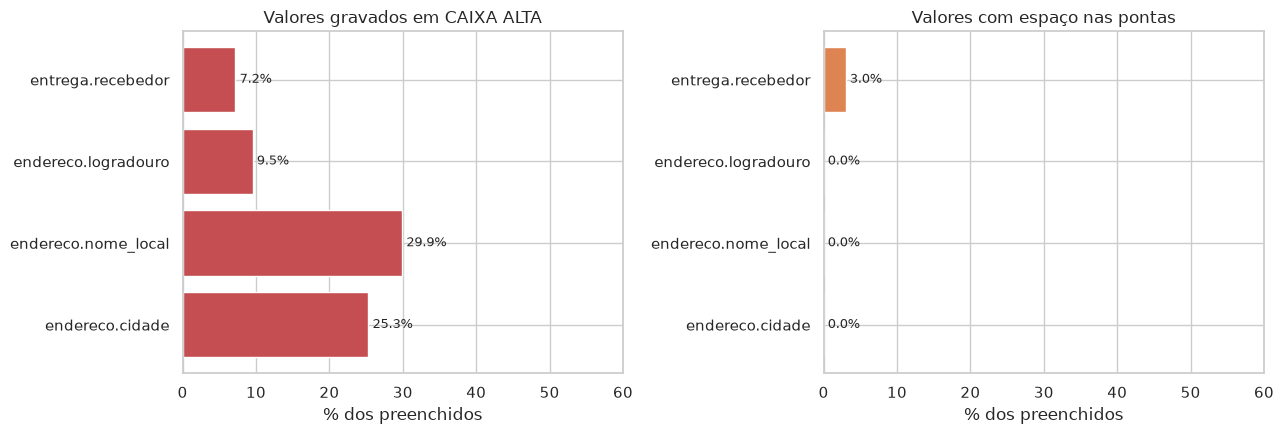

In [25]:
fig, (esquerda, direita) = plt.subplots(1, 2, figsize=(13, 4.5))

resumo = pd.DataFrame([
    {"campo": f"{t}.{c}", **qualidade.texto_inconsistente(tabelas[t], c)}
    for t, c in [("endereco", "cidade"), ("endereco", "nome_local"),
                 ("endereco", "logradouro"), ("entrega", "recebedor")]
])
resumo["pct_caixa_alta"] = 100 * resumo["caixa_alta"] / resumo["total_nao_nulo"]
resumo["pct_espaco"] = 100 * resumo["espaco_nas_pontas"] / resumo["total_nao_nulo"]

esquerda.barh(resumo["campo"], resumo["pct_caixa_alta"], color="#C44E52")
esquerda.set_title("Valores gravados em CAIXA ALTA")
esquerda.set_xlabel("% dos preenchidos")

direita.barh(resumo["campo"], resumo["pct_espaco"], color="#DD8452")
direita.set_title("Valores com espaço nas pontas")
direita.set_xlabel("% dos preenchidos")

for eixo in (esquerda, direita):
    eixo.bar_label(eixo.containers[0], fmt="%.1f%%", padding=3, fontsize=9)
    eixo.set_xlim(0, max(60, eixo.get_xlim()[1] * 1.15))

plt.tight_layout()
plt.show()

## Nota Técnica

**Observado:** o texto digitado por pessoas é o ponto mais frágil da base, e por
larga margem.

| Campo | Vício | Linhas |
|---|---|---|
| `endereco.cidade` | gravado em CAIXA ALTA | 4.986 |
| `endereco.nome_local` | gravado em CAIXA ALTA | 5.893 |
| `endereco.logradouro` | gravado em CAIXA ALTA | 1.880 |
| `entrega.recebedor` | CAIXA ALTA | 101.065 |
| `entrega.recebedor` | espaço sobrando nas pontas | 42.147 |

Somando as variações de caixa e de acentuação, **65 cidades existem em mais de
uma grafia**. São Paulo, por exemplo, aparece como `São Paulo`, `SÃO PAULO`,
`Sao Paulo` e `SAO PAULO`, quatro registros diferentes para a mesma cidade.

**Por que importa:** este é o defeito que mais distorce análise sem levantar
suspeita. Um agrupamento por cidade devolve quatro linhas para São Paulo, cada
uma com uma fatia do volume. Quem olhar o relatório vai concluir que a operação é
mais pulverizada do que realmente é, e nenhuma das quatro linhas estará "errada"
o suficiente para chamar atenção.

O mesmo vale para `recebedor`: com espaço sobrando e caixa inconsistente, contar
quantas entregas cada pessoa recebeu produz nomes repetidos.

**Ação:** padronizar no Silver (remover espaços nas pontas, aplicar capitalização
consistente, comparar sem acento). E reportar ao dono do sistema, porque a causa
está na captura: o campo aceita qualquer coisa e não normaliza na entrada.

In [26]:
achados.anotar(
    tabela="endereco", coluna="cidade",
    achado="mesma cidade gravada em até 4 grafias diferentes (caixa e acento)",
    linhas=4986, total=len(endereco), severidade="alta",
    impacto="agrupamento por cidade quebra em várias linhas e subestima a concentração",
    acao="normalizar no Silver e reportar ausência de padronização na captura",
)
achados.anotar(
    tabela="entrega", coluna="recebedor",
    achado="nome do recebedor com caixa inconsistente e espaço nas pontas",
    linhas=101065 + 42147, total=len(entrega), severidade="media",
    impacto="impede contar entregas por recebedor sem tratamento prévio",
    acao="aplicar trim e capitalização no Silver",
)
achados.anotar(
    tabela="endereco", coluna="logradouro",
    achado="tipo de logradouro ora abreviado (R., Av.) ora por extenso",
    linhas=10030, total=len(endereco), severidade="baixa",
    impacto="dificulta comparar endereços e integrar com serviços de geolocalização",
    acao="padronizar no Silver",
)
print(f"achados registrados: {len(achados)}")

achados registrados: 6


# 9. Consistência temporal 

Fase que termina antes de começar, entrega antes do embarque, evento fora de ordem.

In [27]:
pedido_fase = tabelas["pedido_fase"]
ordem_coleta = tabelas["ordem_coleta"]
pedido = tabelas["pedido"]

verificacoes = [
    ("fase: saída antes da entrada",
     qualidade.ordem_temporal(pedido_fase, "dt_entrada", "dt_saida")),
    ("ordem de coleta: conclusão antes da emissão",
     qualidade.ordem_temporal(ordem_coleta, "dt_emissao", "dt_conclusao")),
]

for rotulo, resultado in verificacoes:
    print(f"  {rotulo}")
    print(f"      comparações {resultado['comparacoes']:>12,}")
    print(f"      invertidos  {resultado['invertidos']:>12,}  ({resultado['pct']}%)")

  fase: saída antes da entrada
      comparações   14,582,047
      invertidos             0  (0.0%)
  ordem de coleta: conclusão antes da emissão
      comparações    3,662,275
      invertidos             0  (0.0%)


In [28]:
# entre tabelas: a carga não pode chegar antes de embarcar
com_embarque = entrega.merge(minuta[["id", "dt_expedicao"]],
                             left_on="minuta_id", right_on="id", suffixes=("", "_min"))
chegada_impossivel = qualidade.ordem_temporal(com_embarque, "dt_expedicao", "dt_chegada")
print(f"entrega chegando antes do embarque: {chegada_impossivel['invertidos']:,} "
      f"de {chegada_impossivel['comparacoes']:,}")

com_pedido = entrega.merge(pedido[["id", "dt_solicitacao"]],
                           left_on="pedido_id", right_on="id", suffixes=("", "_ped"))
antes_do_pedido = qualidade.ordem_temporal(com_pedido, "dt_solicitacao", "dt_chegada")
print(f"entrega antes da solicitação:       {antes_do_pedido['invertidos']:,} "
      f"de {antes_do_pedido['comparacoes']:,}")

entrega chegando antes do embarque: 0 de 2,663,634


entrega antes da solicitação:       0 de 2,663,634


## Nota Técnica

**Observado:** nenhuma inversão temporal foi encontrada. Nas 14,6 milhões de
passagens de fase, nenhuma termina antes de começar. Nas 2,6 milhões de entregas,
nenhuma chega antes do embarque ou antes do próprio pedido existir.

**Por que importa:** número impossível é o defeito mais fácil de detectar e o mais
constrangedor de descobrir tarde, porque não há como explicar ao cliente um
relatório que mostra entrega ocorrida antes do pedido. A ausência total deles
indica que a origem grava os eventos em sequência, sem edição retroativa de data.

Vale registrar isso no relatório como ponto forte. Sistemas que permitem digitar
data manualmente costumam acumular esse tipo de inconsistência, e a comparação
favorece o cliente.

**Ação:** nenhuma. Manter a verificação no pipeline como teste de regressão: se um
dia aparecer, a causa será mudança na origem, e é bom descobrir na hora.

# 10. Integridade referencial

Órfãos dentro do operacional e na ligação com o financeiro

In [29]:
relacoes = [
    ("pedido", "cliente_id", "organizacao"),
    ("pedido", "endereco_id", "endereco"),
    ("pedido_item", "pedido_id", "pedido"),
    ("pedido_item", "item_id", "item"),
    ("pedido_fase", "pedido_id", "pedido"),
    ("entrega", "pedido_id", "pedido"),
    ("entrega", "minuta_id", "minuta"),
    ("ocorrencia", "pedido_id", "pedido"),
    ("ordem_coleta", "local_estoque_id", "local_estoque"),
]

for filho, fk, pai in relacoes:
    if pai not in tabelas:
        print(f"  {filho}.{fk:<20} -> {pai}: tabela ausente do Bronze (fora do contrato)")
        continue
    resultado = qualidade.orfaos(tabelas[filho], fk, tabelas[pai])
    print(f"  {filho}.{fk:<20} -> {pai:<14} "
          f"{resultado['orfaos']:>3} órfãos de {resultado['referencias']:>10,}")

  pedido.cliente_id           -> organizacao      0 órfãos de  1,776,391
  pedido.endereco_id          -> endereco         0 órfãos de  1,776,391


  pedido_item.pedido_id            -> pedido           0 órfãos de  7,728,077
  pedido_item.item_id              -> item             0 órfãos de  7,728,077


  pedido_fase.pedido_id            -> pedido           0 órfãos de 14,589,229
  entrega.pedido_id            -> pedido           0 órfãos de  2,664,991
  entrega.minuta_id            -> minuta           0 órfãos de  2,664,991


  ocorrencia.pedido_id            -> pedido           0 órfãos de     48,793
  ordem_coleta.local_estoque_id     -> local_estoque: tabela ausente do Bronze (fora do contrato)


## Nota Técnica

**Observado:** nenhum órfão dentro do domínio operacional. Toda referência aponta
para um registro existente.

Uma relação não pôde ser verificada porque `local_estoque` não faz parte do
contrato de ingestão: ela não é usada por nenhum dos dois relatórios aprovados, e
o princípio de minimização determinou que só entra no Bronze o que foi acordado.

**Por que importa:** integridade intacta é consequência de o sistema usar chave
estrangeira de verdade, e não apenas convenção de nomes. Isso permite fazer
junções sem medo de perder linha pelo caminho, o que é uma garantia que nem todo
sistema oferece.

A prova real de integridade, porém, vem na ligação **entre os dois sistemas**:
operação e financeiro não têm chave estrangeira entre si, apenas o número do
pedido como chave de negócio. Essa reconciliação é analisada no notebook do
domínio financeiro, e é lá que os órfãos aparecem.

**Ação:** nenhuma no operacional. Registrar como ponto forte.

# 11. Números impossíveis 

Peso, volume e quantidade negativos ou fora de faixa plausível

In [30]:
testes = [
    ("pedido.peso_teorico_kg <= 0", (pedido["peso_teorico_kg"] <= 0).sum()),
    ("pedido.volume_teorico_m3 <= 0", (pedido["volume_teorico_m3"] <= 0).sum()),
    ("pedido_item.quantidade <= 0", (tabelas["pedido_item"]["quantidade"] <= 0).sum()),
    ("estoque_snapshot.m3_ocupado < 0", (tabelas["estoque_snapshot"]["m3_ocupado"] < 0).sum()),
    ("estoque_snapshot.qtde_saldo < 0", (tabelas["estoque_snapshot"]["qtde_saldo"] < 0).sum()),
    ("prazo de entrega anterior ao pedido",
     (pd.to_datetime(pedido["dt_prazo_entrega"]) < pedido["dt_solicitacao"]).sum()),
]

for rotulo, quantidade in testes:
    print(f"  {rotulo:<42} {quantidade:>10,}")

  pedido.peso_teorico_kg <= 0                         0
  pedido.volume_teorico_m3 <= 0                       0
  pedido_item.quantidade <= 0                         0
  estoque_snapshot.m3_ocupado < 0                     0
  estoque_snapshot.qtde_saldo < 0                     0
  prazo de entrega anterior ao pedido                 0


In [31]:
# faixa plausível: o peso aferido deveria ficar perto do teórico
aferidos = pedido.dropna(subset=["peso_real_kg", "peso_teorico_kg"]).copy()
aferidos["razao"] = aferidos["peso_real_kg"] / aferidos["peso_teorico_kg"]

print("Razão entre peso aferido e peso teórico:")
print(aferidos["razao"].describe(percentiles=[0.01, 0.5, 0.99]).round(3).to_string())
fora_da_faixa = ((aferidos["razao"] < 0.5) | (aferidos["razao"] > 2)).sum()
print(f"\n  fora da faixa de 0,5x a 2x: {fora_da_faixa:,}")

Razão entre peso aferido e peso teórico:
count   1,719,124.00
mean            1.04
std             0.08
min             0.90
1%              0.90
50%             1.04
99%             1.18
max             1.18

  fora da faixa de 0,5x a 2x: 0


## Nota Técnica

**Observado:** nenhum valor impossível. Peso, volume e quantidade são sempre
positivos; nenhum saldo de estoque é negativo; nenhum prazo de entrega antecede o
próprio pedido.

A comparação entre peso aferido e peso teórico mostra razão concentrada em torno
de 1, dentro de uma faixa estreita. Isso indica que a pesagem confirma a
estimativa, sem discrepância sistemática que sugerisse erro de unidade (quilos
lançados como gramas, por exemplo) ou troca de campo.

**Por que importa:** valor negativo em quantidade ou saldo costuma indicar
estorno lançado sem tratamento, e é o tipo de coisa que passa por toda a cadeia e
aparece como um total menor no fechamento do mês. A ausência dele aumenta a
confiança nos indicadores de volume.

**Ação:** nenhuma. Manter os testes no pipeline como verificação contínua.

# 12. Sinais de vazamento

Campos que só existem depois do instante da previsão

O modelo preditivo responderá, sobre um pedido **em andamento**, qual o risco de
ele atrasar. O instante da previsão foi definido com a operação: logo após o
**Planejamento (PL)**.

A regra que nasce disso é simples de enunciar e fácil de violar sem perceber:

> No instante em que a previsão é feita, **metade do processo ainda não aconteceu**.
> Tudo que só é preenchido depois desse instante está vazio quando o modelo é
> chamado, e portanto não pode ser usado.

Imagine o painel rodando às 8h da manhã, sobre a carteira em andamento. Um pedido
parado em Planejamento **ainda não tem nota fiscal**, porque a nota nasce quatro
etapas adiante. Não é que a informação seja perigosa: **ela não existe**.

O estrago não aparece durante o desenvolvimento, e é isso que torna o erro tão
comum:

1. o histórico usado no treino contém apenas pedidos que terminaram, e nele
   **todos** têm nota fiscal, peso aferido e volume aferido;
2. o modelo aprende a se apoiar nessas colunas e vai muito bem na avaliação;
3. em produção, chega um pedido em Planejamento com esses campos vazios;
4. o modelo, que aprendeu a confiar neles, perde a referência principal e passa a
   errar, sem que nada no código tenha quebrado.

É o equivalente a treinar alguém para dirigir sempre com GPS e retirar o GPS no
dia da prova.

**O que continua permitido, e é importante:** os tempos das etapas que **já
aconteceram** são informação legítima e valiosa. Um pedido que ficou quarenta
horas na aprovação já está avisando que vai mal. A restrição vale apenas para o
que ainda está no futuro.

In [32]:
fase = tabelas["fase"].sort_values("ordem")
print("A esteira do pedido e o corte da previsão:\n")
for _, linha in fase.iterrows():
    passou = linha["ordem"] <= 4
    situacao = "JÁ ACONTECEU  (pode virar feature)" if passou else "ainda não aconteceu"
    marca = "   <== a previsão é feita aqui" if linha["codigo"] == "PL" else ""
    print(f"  {int(linha['ordem']):>2}. {linha['codigo']}  {linha['nome']:<32} {situacao}{marca}")

A esteira do pedido e o corte da previsão:

   1. EA  Em Aprovação                     JÁ ACONTECEU  (pode virar feature)
   2. PC  Pré-Conferência                  JÁ ACONTECEU  (pode virar feature)
   3. DC  Distribuição de Cotas            JÁ ACONTECEU  (pode virar feature)
   4. PL  Planejamento                     JÁ ACONTECEU  (pode virar feature)   <== a previsão é feita aqui
   5. EX  Em Análise (urgência extrema)    ainda não aconteceu
   6. CF  Coleta Física                    ainda não aconteceu
   7. ME  Manuseio                         ainda não aconteceu
   8. EN  Emissão (NF-e)                   ainda não aconteceu
   9. EC  Expedição                        ainda não aconteceu
  10. CE  Confirmação de Entrega           ainda não aconteceu


In [33]:
# o que existe e o que não existe no instante da previsão
disponivel = {
    "dt_solicitacao": "registrada na abertura do pedido",
    "cliente_id / endereco_id": "definidos na abertura",
    "peso_teorico_kg / volume_teorico_m3": "calculados do catálogo, na entrada",
    "dt_prazo_entrega": "prometido no planejamento",
    "canal / nivel_servico / tipo_atendimento": "definidos na abertura",
    "tempo das fases EA, PC, DC, PL": "já decorreram",
}
indisponivel = {
    "nf_numero": "emitida na fase EN, quatro etapas depois",
    "peso_real_kg": "aferido no manuseio (ME)",
    "volume_real_m3": "aferido no manuseio (ME)",
    "minuta / transportador / veículo": "definidos na expedição (EC)",
    "dt_chegada / recebedor": "só existem quando a entrega acontece",
    "tempo das fases CF, ME, EN, EC, CE": "ainda não decorreram",
}

print("DISPONÍVEL no instante da previsão (pode virar feature):")
for campo, quando in disponivel.items():
    print(f"   {campo:<42} {quando}")

print("\nINDISPONÍVEL (usar seria prever com informação do futuro):")
for campo, quando in indisponivel.items():
    print(f"   {campo:<42} {quando}")

DISPONÍVEL no instante da previsão (pode virar feature):
   dt_solicitacao                             registrada na abertura do pedido
   cliente_id / endereco_id                   definidos na abertura
   peso_teorico_kg / volume_teorico_m3        calculados do catálogo, na entrada
   dt_prazo_entrega                           prometido no planejamento
   canal / nivel_servico / tipo_atendimento   definidos na abertura
   tempo das fases EA, PC, DC, PL             já decorreram

INDISPONÍVEL (usar seria prever com informação do futuro):
   nf_numero                                  emitida na fase EN, quatro etapas depois
   peso_real_kg                               aferido no manuseio (ME)
   volume_real_m3                             aferido no manuseio (ME)
   minuta / transportador / veículo           definidos na expedição (EC)
   dt_chegada / recebedor                     só existem quando a entrega acontece
   tempo das fases CF, ME, EN, EC, CE         ainda não decorreram


In [34]:
# A PROVA: na carteira em andamento, quem já tem nota fiscal?
em_voo = pedido_fase[pedido_fase["dt_saida"].isna()][["pedido_id", "fase_id"]]
em_voo = em_voo.merge(fase[["id", "codigo", "nome", "ordem"]], left_on="fase_id", right_on="id")
em_voo = em_voo.merge(pedido[["id", "nf_numero", "peso_real_kg"]],
                      left_on="pedido_id", right_on="id", suffixes=("", "_ped"))

resumo_voo = (em_voo.groupby(["ordem", "codigo", "nome"])
              .agg(pedidos=("pedido_id", "count"),
                   com_nf=("nf_numero", lambda s: s.notna().sum()),
                   com_peso_aferido=("peso_real_kg", lambda s: s.notna().sum()))
              .reset_index().sort_values("ordem"))
resumo_voo["pct_com_nf"] = (100 * resumo_voo["com_nf"] / resumo_voo["pedidos"]).round(1)

print("Carteira em andamento: o que está preenchido em cada fase\n")
print(resumo_voo[["codigo", "nome", "pedidos", "com_nf", "pct_com_nf",
                  "com_peso_aferido"]].to_string(index=False))

Carteira em andamento: o que está preenchido em cada fase

codigo                          nome  pedidos  com_nf  pct_com_nf  com_peso_aferido
    EA                  Em Aprovação     1008       0        0.00                 0
    PC               Pré-Conferência      446       0        0.00                 0
    DC         Distribuição de Cotas      106       0        0.00                 0
    PL                  Planejamento      434       0        0.00                 0
    EX Em Análise (urgência extrema)        2       0        0.00                 0
    CF                 Coleta Física      690       0        0.00                 0
    ME                      Manuseio      563       0        0.00                 0
    EN                Emissão (NF-e)      117       0        0.00               113
    EC                     Expedição      685     685      100.00               658
    CE        Confirmação de Entrega     3131    3131      100.00              3029


## Nota Técnica

**Observado:** a carteira em andamento comprova a regra na prática. Os pedidos
parados nas fases anteriores à emissão têm **zero** notas fiscais e **zero** pesos
aferidos. Os que já passaram da emissão têm tudo preenchido.

| Coluna | Nasce em | Situação no instante da previsão |
|---|---|---|
| `nf_numero` | Emissão (EN) | vazia |
| `peso_real_kg` | Manuseio (ME) | vazia |
| `volume_real_m3` | Manuseio (ME) | vazia |

Um modelo treinado com essas colunas aprenderia que "ter nota fiscal" antecipa
entrega no prazo. Só que ter nota fiscal não é causa de nada: é apenas sinal de
que o pedido já percorreu quase todo o caminho. Em produção, no momento em que a
pergunta é feita, esse sinal não está lá.

**Por que importa:** este é o erro que mais destrói projeto de predição, e ele não
dá aviso durante o desenvolvimento. A métrica no teste fica excelente, o modelo é
aprovado, entra em produção e passa a errar, sem que nenhuma linha de código
tenha falhado.

**A distinção que salva o modelo:** `peso_teorico_kg` e `volume_teorico_m3` **podem**
ser usados, porque são calculados na entrada do pedido a partir do catálogo. É a
versão **aferida** que chega tarde demais. Duas colunas com nomes parecidos, uma
utilizável e outra proibida.

E vale reforçar o que **continua permitido**: a duração das fases já concluídas.
Um pedido que consumiu quarenta horas na aprovação carrega informação legítima
sobre o próprio risco, e é justamente disso que o modelo vai se alimentar.

**Ação:** excluir as três colunas do conjunto de variáveis e registrar a regra na
documentação de atributos. O tema volta com profundidade na etapa de engenharia
de atributos, onde cada variável candidata será avaliada por esse mesmo critério:
*esta informação existe no instante em que a pergunta é feita?*

## 12.1. O mesmo pedido, em dois momentos

A tabela abaixo compara um pedido **parado no Planejamento agora** com um pedido
**já concluído** do histórico. A coluna da esquerda é o que o modelo enxerga
quando a pergunta é feita; a da direita é o que existe no histórico usado para
treinar.

Repare no formato dos vazios: eles não estão espalhados, estão **do meio para
baixo**. É uma régua descendo pela linha, parando na fase atual.

In [35]:
# um pedido parado no Planejamento agora
abertas = pedido_fase[pedido_fase["dt_saida"].isna()].copy()
abertas["codigo"] = abertas["fase_id"].map(fase.set_index("id")["codigo"])
pedido_em_voo = abertas[abertas["codigo"] == "PL"]["pedido_id"].iloc[0]

# um pedido já concluído, do histórico
pedido_concluido = pedido[~pedido["id"].isin(abertas["pedido_id"])]["id"].iloc[0]


def retrato(pedido_id, rotulo):
    """Monta a linha do relatório como ela está NESTE momento."""
    linha = pedido[pedido["id"] == pedido_id].iloc[0]
    fases_do_pedido = pedido_fase[pedido_fase["pedido_id"] == pedido_id].copy()
    fases_do_pedido["codigo"] = fases_do_pedido["fase_id"].map(fase.set_index("id")["codigo"])
    entregas = entrega[entrega["pedido_id"] == pedido_id]

    tempos = {}
    for _, etapa in fases_do_pedido.iterrows():
        if pd.notna(etapa["dt_saida"]):
            horas = (etapa["dt_saida"] - etapa["dt_entrada"]).total_seconds() / 3600
            tempos[etapa["codigo"]] = f"{horas:.0f}h"
        else:
            tempos[etapa["codigo"]] = "EM ANDAMENTO"

    return pd.Series({
        "SS": linha["numero"],
        "Data Solicitação": str(linha["dt_solicitacao"])[:16],
        "Prazo ao Cliente": str(linha["dt_prazo_entrega"]),
        "Peso TEÓRICO": f"{linha['peso_teorico_kg']:.1f} kg",
        "Horas EA (aprovação)": tempos.get("EA", "—"),
        "Horas PC (pré-conferência)": tempos.get("PC", "—"),
        "Horas PL (planejamento)": tempos.get("PL", "—"),
        "Horas CF (coleta)": tempos.get("CF", "—"),
        "Horas ME (manuseio)": tempos.get("ME", "—"),
        "Horas EN (emissão)": tempos.get("EN", "—"),
        "Horas EC (expedição)": tempos.get("EC", "—"),
        "Nota fiscal": linha["nf_numero"] if pd.notna(linha["nf_numero"]) else "—",
        "Peso AFERIDO": (f"{linha['peso_real_kg']:.1f} kg"
                         if pd.notna(linha["peso_real_kg"]) else "—"),
        "Embarcado em minuta": "sim" if len(entregas) else "—",
        "Data da entrega": (str(entregas["dt_chegada"].max())[:16]
                            if len(entregas) and entregas["dt_chegada"].notna().any() else "—"),
    }, name=rotulo)


pd.concat([retrato(pedido_em_voo, "EM ANDAMENTO (o que a produção envia)"),
           retrato(pedido_concluido, "CONCLUÍDO (o que o treino tem)")], axis=1)

,EM ANDAMENTO (o que a produção envia),CONCLUÍDO (o que o treino tem)
SS,SS1771374,SS0000001
Data Solicitação,2026-07-27 08:56,2016-02-26 11:13
Prazo ao Cliente,2026-08-17,2016-03-09
Peso TEÓRICO,347.0 kg,50.0 kg
Horas EA (aprovação),6h,5h
Horas PC (pré-conferência),2h,64h
Horas PL (planejamento),EM ANDAMENTO,6h
Horas CF (coleta),—,23h
Horas ME (manuseio),—,19h
Horas EN (emissão),—,2h


## 12.2. E se preenchermos os campos vazios?

Uma saída que costuma ser proposta: preencher as etapas que ainda não ocorreram
com algum valor neutro, por exemplo marcá-las como "no prazo", para que a linha
fique completa e o modelo consiga processá-la. A ideia é intuitiva e merece ser
examinada com cuidado, porque tem uma parte certa e uma parte perigosa.

**A parte certa: reavaliar o pedido a cada mudança de fase.** Esse é o desenho
correto de um sistema de risco em operação. O pedido é pontuado ao entrar,
pontuado de novo quando avança, e a previsão fica mais precisa conforme surge
informação real. O painel deixa de mostrar um número fixo e passa a mostrar uma
trajetória: entrou com 30% de risco, subiu para 55% quando a coleta atrasou.

**A parte perigosa: atribuir "no prazo" a uma etapa que não aconteceu.** Isso é
afirmar algo sobre o futuro, e traz três consequências:

1. **Viés otimista sistemático.** Se toda etapa pendente chega marcada como no
   prazo, o modelo enxerga sempre o cenário favorável e subestima o risco. É o
   oposto do que a operação precisa, já que deixar de avisar um atraso custa mais
   caro que um alarme falso.
2. **Treino e produção passam a falar línguas diferentes.** No histórico, "no
   prazo" significa que a etapa aconteceu e cumpriu o prazo. Em produção passaria
   a significar que a etapa não aconteceu. Mesmo rótulo, dois sentidos.
3. **Perde-se o sinal mais forte do problema.** "Ainda não iniciou a coleta e
   faltam dois dias para o prazo" é um alerta poderoso. Preenchido como no prazo,
   esse alerta desaparece.

**O que funciona, preservando a ideia da reavaliação:**

| Abordagem | O que faz |
|---|---|
| Indicador de ausência | uma coluna `coleta_concluida` (sim/não) ao lado do tempo. O modelo aprende que "não concluída" tem significado próprio, sem que se afirme se foi bom ou ruim |
| Tempo decorrido | em vez de "horas na coleta", que exige a coleta ter terminado, usar "horas desde a abertura do pedido". Sempre existe e sempre é comparável |
| Folga restante | "faltam três dias para o prazo e o pedido está na quarta de dez fases". Combina tempo e progresso, e é a variável mais honesta deste problema |

As três dizem a verdade sobre o estado atual sem inventar futuro, e todas
funcionam com a reavaliação a cada leitura.

**Ação:** a construção dessas variáveis é trabalho da etapa de engenharia de
atributos. O que fica decidido aqui é o critério de aceitação: **uma variável só
entra no modelo se existir, com o mesmo significado, no instante em que a
pergunta é feita.**

In [36]:
achados.anotar(
    tabela="pedido", coluna="nf_numero, peso_real_kg, volume_real_m3",
    achado="colunas preenchidas depois do instante da previsão (risco de vazamento)",
    linhas=int(pedido[["nf_numero", "peso_real_kg", "volume_real_m3"]].notna().any(axis=1).sum()),
    total=len(pedido), severidade="alta",
    impacto="inflam a métrica no treino e derrubam o modelo em produção",
    acao="excluir do conjunto de variáveis; usar as versões teóricas",
)
print(f"achados registrados: {len(achados)}")

achados registrados: 7


# 13. Fechamento

Consolidação dos achados, severidades e recomendações

In [37]:
resumo = achados.resumo()
print("Achados por severidade:\n")
print(resumo.to_string(index=False))
print(f"\nTotal: {len(achados)} achados")

Achados por severidade:

severidade  achados
      alta        4
     media        2
     baixa        1

Total: 7 achados


In [38]:
tabela_achados = achados.tabela()
tabela_achados[["severidade", "tabela", "coluna", "achado", "linhas", "pct"]]

,severidade,tabela,coluna,achado,linhas,pct
6,alta,pedido,"nf_numero, peso_real_kg, volume_real_m3",colunas preenchidas depois do instante da previsão (risco de vazamento),1772377,99.77
1,alta,entrega,recebedor,transferência para base sem registro de quem recebeu a carga,1239076,46.49
3,alta,endereco,cidade,mesma cidade gravada em até 4 grafias diferentes (caixa e acento),4986,25.31
0,alta,item,valor_unitario,SKU com saldo em estoque e sem valor fiscal (cobertura fiscal),79,1.16
4,media,entrega,recebedor,nome do recebedor com caixa inconsistente e espaço nas pontas,143212,5.37
2,media,endereco,logradouro/cidade,mesmo endereço cadastrado mais de uma vez com grafias diferentes,350,1.78
5,baixa,endereco,logradouro,"tipo de logradouro ora abreviado (R., Av.) ora por extenso",10030,50.92


In [39]:
tabela_achados[["severidade", "tabela", "coluna", "impacto", "acao"]]

,severidade,tabela,coluna,impacto,acao
6,alta,pedido,"nf_numero, peso_real_kg, volume_real_m3",inflam a métrica no treino e derrubam o modelo em produção,excluir do conjunto de variáveis; usar as versões teóricas
1,alta,entrega,recebedor,sem canhoto não há como arbitrar divergência entre transportadora e base em caso de perda ou avaria,tornar o campo obrigatório no aplicativo do motorista (ação na origem)
3,alta,endereco,cidade,agrupamento por cidade quebra em várias linhas e subestima a concentração,normalizar no Silver e reportar ausência de padronização na captura
0,alta,item,valor_unitario,impede calcular seguro por ad valorem e a valorização do estoque parado,reportar ao cliente para completar o cadastro na origem
4,media,entrega,recebedor,impede contar entregas por recebedor sem tratamento prévio,aplicar trim e capitalização no Silver
2,media,endereco,logradouro/cidade,infla a contagem de pontos atendidos e divide o histórico do mesmo local,criar chave normalizada no Silver; fusão de cadastro é decisão do cliente
5,baixa,endereco,logradouro,dificulta comparar endereços e integrar com serviços de geolocalização,padronizar no Silver


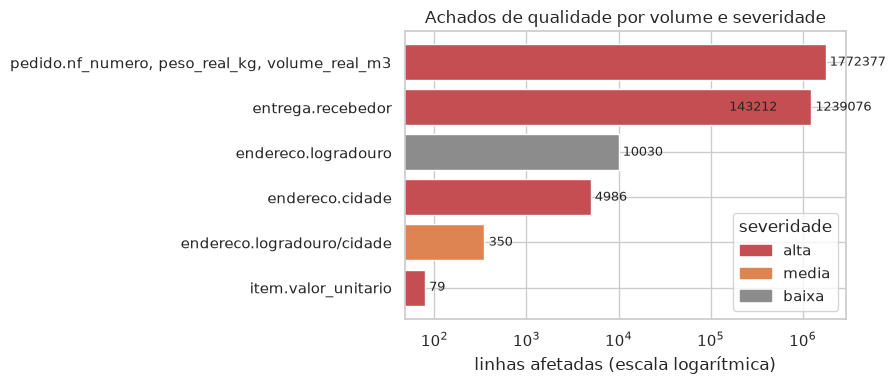

In [40]:
fig, eixo = plt.subplots(figsize=(9, 4))
cores = {"alta": "#C44E52", "media": "#DD8452", "baixa": "#8C8C8C"}
dados = tabela_achados.sort_values("linhas")
barras = eixo.barh(dados["tabela"] + "." + dados["coluna"], dados["linhas"],
                   color=[cores[s] for s in dados["severidade"]])
eixo.set_xscale("log")
eixo.set_xlabel("linhas afetadas (escala logarítmica)")
eixo.set_title("Achados de qualidade por volume e severidade")
eixo.bar_label(barras, fmt="%.0f", padding=3, fontsize=9)
marcadores = [plt.Rectangle((0, 0), 1, 1, color=cor) for cor in cores.values()]
eixo.legend(marcadores, cores.keys(), title="severidade", loc="lower right")
plt.tight_layout()
plt.show()

## Nota Técnica de fechamento

**O que foi examinado:** as 18 tabelas do domínio operacional, 133 colunas e 31,1
milhões de linhas, na carga do Bronze identificada na seção 2. O exame cobriu
completude, unicidade, domínio dos categóricos, consistência de texto, ordem
temporal, integridade referencial, valores impossíveis e risco de vazamento.

**O veredicto geral: a base é sólida na estrutura e frágil no texto digitado.**

O que o sistema de origem controla, ele controla bem. Não há chave duplicada, não
há referência órfã, não há data invertida, não há quantidade negativa e os campos
categóricos contêm apenas valores previstos. Isso é resultado de modelagem com
chave estrangeira e restrição de domínio, e merece ser dito ao cliente, porque
não é o que se encontra na maioria dos sistemas.

Os problemas se concentram exatamente onde o banco não consegue impedir: **texto
livre digitado por pessoas**. Cidade, nome do local, logradouro e recebedor
aparecem em caixa e acentuação inconsistentes, ao ponto de a mesma cidade existir
em quatro grafias diferentes.

**O achado mais relevante para o negócio** é a cobertura fiscal: 79 itens com
saldo em estoque e sem valor unitário cadastrado. Sem esse valor não há como
calcular o seguro por ad valorem nem valorizar o estoque parado.

**O achado mais relevante para o projeto** é o risco de vazamento: três colunas do
pedido só são preenchidas depois do instante em que a previsão será feita. Elas
precisam ficar fora do modelo, e essa decisão precisa estar registrada, porque
ela custa métrica no papel e salva o modelo em produção.

**Recomendações ao cliente, em ordem de prioridade:**

1. **Completar o valor unitário dos itens com saldo em estoque.** É a única
   recomendação que exige ação na origem, e tem efeito financeiro direto.
2. **Padronizar a captura de texto no cadastro** (capitalização automática e
   remoção de espaços na entrada). Enquanto isso não acontece, o tratamento fica
   por conta do pipeline, mas a causa continua gerando dado novo com o mesmo
   defeito.
3. **Avaliar a fusão dos 174 grupos de endereços duplicados.** A decisão é do
   cliente, porque envolve histórico; o pipeline apenas sinaliza.

**O que o pipeline vai tratar na camada Silver:** normalização de texto
(capitalização, espaços, comparação sem acento), chave normalizada de endereço
para agrupamento, e exclusão das colunas com risco de vazamento do conjunto de
variáveis do modelo.

**Próximo passo:** escrever os scripts de tratamento e carga da camada Silver,
usando as ações registradas na tabela de achados como especificação.